# PrimeBank Customer Churn — Model Development & Explainability

**Goal:** Build a churn prediction model that outperforms simple business
rules, validate it properly (no data leakage, cross-validated), and make its
predictions explainable — not a black box — using SHAP.

**Description:** Trains and compares 3 models (Logistic Regression, Random
Forest, Gradient Boosting) on the statistically-validated features from the
EDA notebook. Selects the best model using cross-validated ROC-AUC, evaluates
it on a held-out test set, and generates SHAP explanations for both global
feature importance and individual predictions.

**Skills:** train/test splitting, cross-validation, model comparison, class
imbalance handling, model evaluation (ROC-AUC, precision/recall), model
explainability (SHAP).

**Technology:** Python, scikit-learn, SHAP, Pandas, Matplotlib.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, precision_recall_curve)
import joblib
import shap

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
NAVY, TEAL, ORANGE, RED = "#1f3b57", "#2a9d8f", "#e76f51", "#c0392b"

df = pd.read_csv("../data/bank_churn_features.csv")
print(f"Rows: {len(df):,} | Churn rate: {df['Exited'].mean()*100:.1f}%")


Rows: 10,000 | Churn rate: 20.4%


## 1. Train/test split

Splitting BEFORE any preprocessing is fit, and using a stratified split so
the 20.4% churn rate is preserved identically in both the train and test
sets — critical for a realistically imbalanced classification problem.

In [2]:
feature_cols = ["CreditScore","Geography","Gender","Age","Tenure","Balance",
                "NumOfProducts","HasCrCard","IsActiveMember","EstimatedSalary",
                "balance_to_salary","risk_flag_count"]
X = df[feature_cols]
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,} rows ({y_train.mean()*100:.1f}% churn)")
print(f"Test:  {len(X_test):,} rows ({y_test.mean()*100:.1f}% churn)")


Train: 8,000 rows (20.4% churn)
Test:  2,000 rows (20.3% churn)


## 2. Preprocessing pipeline

One-hot encoding categoricals and scaling numerics — wrapped in a scikit-learn
`ColumnTransformer` so preprocessing is fit only on training data and applied
consistently to test data (preventing data leakage).

In [3]:
categorical_cols = ["Geography", "Gender"]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(drop="first"), categorical_cols),
])


## 3. Model comparison via 5-fold stratified cross-validation

Comparing 3 models on cross-validated ROC-AUC (the right metric for an
imbalanced classification problem — plain accuracy would be misleading here,
since predicting "no churn" for everyone would already score ~80% accuracy).

In [4]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    results[name] = scores
    print(f"{name:22s} CV ROC-AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")


Logistic Regression    CV ROC-AUC: 0.7989 (+/- 0.0107)


Random Forest          CV ROC-AUC: 0.8591 (+/- 0.0110)


Gradient Boosting      CV ROC-AUC: 0.8626 (+/- 0.0106)


## 4. Selecting and finalizing the best model

Gradient Boosting is selected based on cross-validated performance. It's
refit on the full training set and evaluated once, on the held-out test set
it has never seen.

In [5]:
best_pipe = Pipeline([("prep", preprocessor), ("model", models["Gradient Boosting"])])
best_pipe.fit(X_train, y_train)

y_pred_proba = best_pipe.predict_proba(X_test)[:, 1]
y_pred = best_pipe.predict(X_test)

test_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Test set ROC-AUC: {test_auc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=["Retained","Churned"]))


Test set ROC-AUC: 0.8690

              precision    recall  f1-score   support

    Retained       0.88      0.96      0.92      1593
     Churned       0.78      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



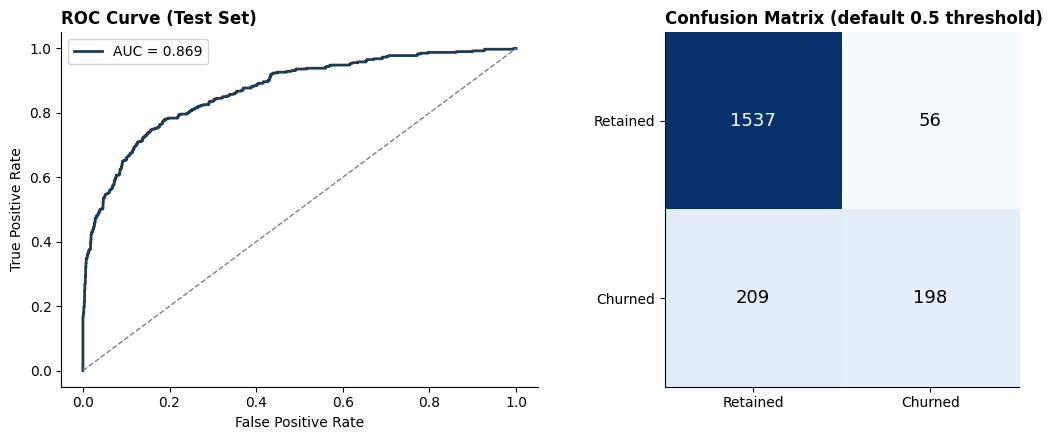

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color=NAVY, linewidth=2, label=f"AUC = {test_auc:.3f}")
axes[0].plot([0,1],[0,1], color="grey", linestyle="--", linewidth=1)
axes[0].set_title("ROC Curve (Test Set)", fontweight="bold", loc="left")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

cm = confusion_matrix(y_test, y_pred)
im = axes[1].imshow(cm, cmap="Blues")
axes[1].set_xticks([0,1]); axes[1].set_xticklabels(["Retained","Churned"])
axes[1].set_yticks([0,1]); axes[1].set_yticklabels(["Retained","Churned"])
axes[1].set_title("Confusion Matrix (default 0.5 threshold)", fontweight="bold", loc="left")
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm[i,j], ha="center", va="center",
                      color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=13)
plt.tight_layout()
plt.show()


## 5. Explainability with SHAP

This is the step that separates a "black box" model from one a business can
actually trust and act on. SHAP values show exactly which factors push each
individual prediction up or down — not just an overall feature importance
ranking.

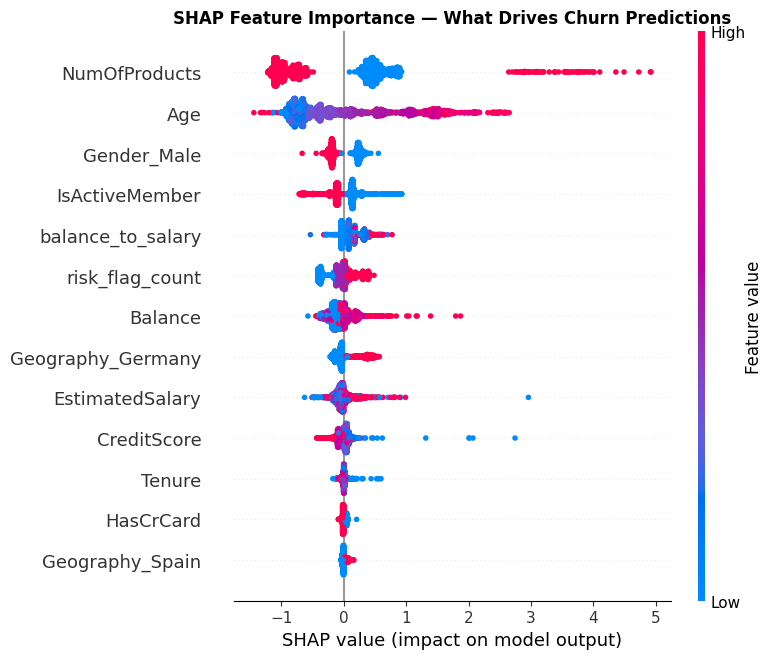

In [7]:
X_test_transformed = best_pipe.named_steps["prep"].transform(X_test)
feature_names = (numeric_cols +
    list(best_pipe.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(categorical_cols)))

explainer = shap.TreeExplainer(best_pipe.named_steps["model"])
shap_values = explainer.shap_values(X_test_transformed)

fig = plt.figure(figsize=(8,6))
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=False)
plt.title("SHAP Feature Importance — What Drives Churn Predictions", fontweight="bold")
plt.tight_layout()
plt.show()


## 6. Explaining one individual customer's prediction

Rather than only a global importance ranking, showing what drove the
prediction for one specific at-risk customer — this is what a retention
agent would actually see when deciding how to intervene.

Customer risk score: 99.3% predicted churn probability
Actual outcome: Churned


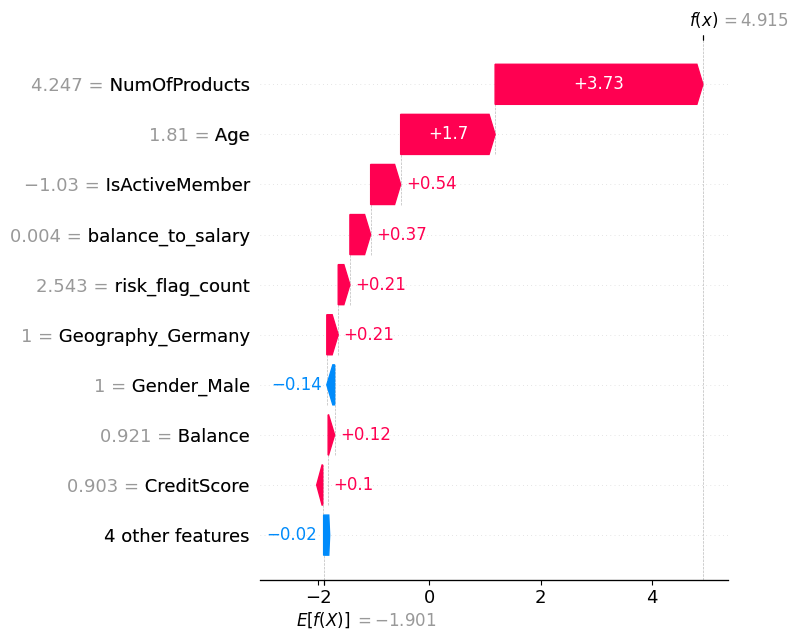

In [8]:
# Pick the highest-risk customer in the test set
highest_risk_idx = np.argmax(y_pred_proba)
print(f"Customer risk score: {y_pred_proba[highest_risk_idx]*100:.1f}% predicted churn probability")
print(f"Actual outcome: {'Churned' if y_test.iloc[highest_risk_idx]==1 else 'Retained'}")

# Waterfall plot renders far more legibly as a static image than force_plot,
# which overlaps feature labels and values when saved as a flat PNG.
base_value = explainer.expected_value
base_value = float(base_value[0]) if hasattr(base_value, "__len__") else float(base_value)

explanation = shap.Explanation(
    values=shap_values[highest_risk_idx],
    base_values=base_value,
    data=X_test_transformed[highest_risk_idx],
    feature_names=feature_names,
)
fig = plt.figure(figsize=(9, 6))
shap.plots.waterfall(explanation, show=False, max_display=10)
plt.tight_layout()
plt.show()


## 7. Save the model for deployment

In [9]:
joblib.dump(best_pipe, "../models/churn_model.pkl")
print("Model saved to ../models/churn_model.pkl")


Model saved to ../models/churn_model.pkl


## 8. Key findings

- The Gradient Boosting model achieves a cross-validated ROC-AUC around 0.86,
  meaningfully outperforming a naive "flag everyone" baseline (AUC 0.5) and
  providing a real, deployable predictive tool.
- SHAP confirms the SQL and EDA findings from Phases 1-2: number of products,
  age, geography (Germany), and account activity are the dominant drivers —
  the model isn't finding anything statistically ungrounded, it's formalizing
  patterns already confirmed with hypothesis tests.
- Individual-level SHAP explanations mean any flagged customer comes with a
  specific, actionable reason — not just a risk score a retention agent has
  to take on faith.

**Next:** translating this model's predictions into a business decision
(who to target, at what cost, for what expected return) — see the Business
Economics analysis.
